In [1]:
# Cell 1: Imports
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import random

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")
print(f"Num GPUs Available: {len(tf.config.experimental.list_physical_devices('GPU'))}")

TensorFlow Version: 2.16.2
Num GPUs Available: 0


In [2]:
# Cell 2: Configuration (No PCA)
# Correct path assuming 'steinmetz_data_downloads' is at the project root,
# and this notebook is in the 'notebooks' subdirectory.
PROCESSED_DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'notebooks/steinmetz_data_downloads'))
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True) # Ensures the directory exists if scripts were to download here
print(f"Data will be loaded from: {PROCESSED_DATA_DIR}")

TARGET_BRAIN_REGION_X = 'VISp' # Input features from VISp
TARGET_BRAIN_REGION_Y = 'MOs'  # Target variable from MOs

# Time window for VISp LFP data (X), relative to an alignment event
X_TIME_WINDOW_START_POST_EVENT_MS = 0 
X_TIME_WINDOW_END_POST_EVENT_MS = 500 

# Time window for MOs LFP data (Y), relative to response_time
Y_TIME_WINDOW_BEFORE_RESPONSE_MS = 100 
Y_TIME_WINDOW_AFTER_RESPONSE_MS = 100 

# LSTM Hyperparameters
N_EPOCHS = 100 
BATCH_SIZE = 64
LSTM_UNITS_1 = 128
LSTM_UNITS_2 = 64
DENSE_UNITS_REG = 64 
DROPOUT_RATE = 0.3
LEARNING_RATE = 0.001 
N_SPLITS_CV = 5
EARLY_STOPPING_PATIENCE = 20

# PCA Configuration - All PCA is disabled
APPLY_PCA_X = False # Disabled
N_PCA_COMPONENTS_X = None # Not used
APPLY_PCA_Y = False # Disabled
N_PCA_COMPONENTS_Y = None # Not used

# Upsampling Configuration (Keep if needed, independent of PCA)
APPLY_UPSAMPLING = True # Or False, depending on your previous choice

Data will be loaded from: /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads


In [3]:
        import os
        data_dir_to_check = "/Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/steinmetz_data_downloads"
        print(f"Checking: {data_dir_to_check}")
        print(f"Exists: {os.path.exists(data_dir_to_check)}")
        print(f"Is directory: {os.path.isdir(data_dir_to_check)}")
        try:
            print(f"Contents: {os.listdir(data_dir_to_check)}")
        except Exception as e:
            print(f"Error listing: {e}")

Checking: /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/steinmetz_data_downloads
Exists: True
Is directory: True
Contents: []


In [4]:
# Cell 3: Data Loading (Corrected for steinmetz_partX.npz and steinmetz_lfp.npz)


def load_steinmetz_npz_data(data_dir):
    # --- DEBUG BLOCK START ---
    print(f"[DEBUG] data_dir received by function: {data_dir}")
    try:
        print(f"[DEBUG] Contents of data_dir ({data_dir}) according to os.listdir(): {os.listdir(data_dir)}")
    except Exception as e:
        print(f"[DEBUG] Error listing data_dir: {e}")
    debug_path_part0 = os.path.join(data_dir, 'steinmetz_part0.npz')
    print(f"[DEBUG] Checking path: {debug_path_part0}")
    print(f"[DEBUG] os.path.exists(debug_path_part0): {os.path.exists(debug_path_part0)}")
    print(f"[DEBUG] os.path.isfile(debug_path_part0): {os.path.isfile(debug_path_part0)}")
    # --- DEBUG BLOCK END ---
    alldat_list = []
    # Construct full paths to the specific npz files
    main_npz_files = [os.path.join(data_dir, f'steinmetz_part{j}.npz') for j in range(3)]

    print(f"Loading main data (steinmetz_part*.npz files) from {data_dir}:")
    for f_path in main_npz_files:
        f_name = os.path.basename(f_path)
        if not os.path.isfile(f_path):
            print(f"Error: Main data file {f_name} not found in {data_dir}.")
            raise FileNotFoundError(f"Required main data file {f_name} is missing from {data_dir}. Cannot proceed.")
        print(f"  - Loading {f_name}...")
        try:
            data_part = np.load(f_path, allow_pickle=True)
            # The 'dat' key should contain a list/array of dictionaries, each dict is a session
            if 'dat' in data_part and isinstance(data_part['dat'], (list, np.ndarray)):
                if len(data_part['dat']) > 0 and isinstance(data_part['dat'][0], dict):
                    alldat_list.extend(data_part['dat'])
                else:
                     print(f"Warning: 'dat' in {f_name} is not a list/array of dictionaries as expected.")
            else:
                print(f"Warning: File {f_name} does not contain a 'dat' key, or 'dat' is not a list/array.")
        except Exception as e:
            print(f"Critical error loading {f_name}: {e}")
            raise

    if not alldat_list:
        raise ValueError(f"No main session data could be loaded from {main_npz_files}. Check file contents and paths.")
    print(f"Successfully loaded main data for {len(alldat_list)} sessions.")

    lfp_file_path = os.path.join(data_dir, 'steinmetz_lfp.npz')
    if not os.path.isfile(lfp_file_path):
        raise FileNotFoundError(f"'steinmetz_lfp.npz' not found in {data_dir}. Please ensure it was downloaded correctly.")

    print(f"\nLoading LFP data from: {os.path.basename(lfp_file_path)}...")
    dat_LFP_list = []
    try:
        # The 'dat' key in steinmetz_lfp.npz should also be a list/array of session dictionaries
        dat_LFP_all_sessions_raw = np.load(lfp_file_path, allow_pickle=True)['dat']
        if isinstance(dat_LFP_all_sessions_raw, np.ndarray) and dat_LFP_all_sessions_raw.ndim == 1 and \
           len(dat_LFP_all_sessions_raw) > 0 and isinstance(dat_LFP_all_sessions_raw[0], dict):
            dat_LFP_list = list(dat_LFP_all_sessions_raw)
        elif isinstance(dat_LFP_all_sessions_raw, list) and len(dat_LFP_all_sessions_raw) > 0 and \
             isinstance(dat_LFP_all_sessions_raw[0], dict):
            dat_LFP_list = dat_LFP_all_sessions_raw
        else:
            raise ValueError("'dat' key in LFP file is not in the expected format (list/array of dictionaries).")
        print(f"Successfully loaded LFP data for {len(dat_LFP_list)} sessions.")
    except Exception as e:
        raise ValueError(f"Error loading 'steinmetz_lfp.npz': {e}")

    if len(alldat_list) != len(dat_LFP_list):
        print(f"Warning: Number of main sessions ({len(alldat_list)}) does not match LFP sessions ({len(dat_LFP_list)}).")
        # Adjust to the minimum count if necessary, or handle error as appropriate
        min_sessions = min(len(alldat_list), len(dat_LFP_list))
        if min_sessions == 0:
            raise ValueError("Zero sessions available after aligning main data and LFP data counts.")
        alldat_list = alldat_list[:min_sessions]
        dat_LFP_list = dat_LFP_list[:min_sessions]
        print(f"Adjusted to {min_sessions} sessions for both main data and LFP data.")
        
    return alldat_list, dat_LFP_list

# Load the data using the PROCESSED_DATA_DIR defined in Cell 2
alldat, dat_LFP = load_steinmetz_npz_data(PROCESSED_DATA_DIR)

[DEBUG] data_dir received by function: /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads
[DEBUG] Contents of data_dir (/Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads) according to os.listdir(): ['steinmetz_lfp.npz', 'steinmetz_part0.npz', 'steinmetz_part1.npz', 'steinmetz_part2.npz']
[DEBUG] Checking path: /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads/steinmetz_part0.npz
[DEBUG] os.path.exists(debug_path_part0): True
[DEBUG] os.path.isfile(debug_path_part0): True
Loading main data (steinmetz_part*.npz files) from /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads:
  - Loading steinmetz_part0.npz...
  - Loading steinmetz_part1.npz...
  - Loading steinmetz_part2.npz...
Successfully loaded main data for 39 sessions.

Loading LFP data from: steinmetz_lfp.npz...
Successfully loaded LFP data f

In [5]:
# Cell 4: Helper Function - Mouse Details
mouse_age_data = {
    'Cori': 11, 'Forssmann': 26, 'Hench': 31, 'Lederberg': 15, 
    'Moniz': 30, 'Muller': 17, 'Radnitz': 20, 'Richards': 26, 
    'Tatum': 15, 'Theiler': 46 
}
YOUNGER_THRESHOLD_WEEKS = 20 

def get_mouse_details_by_session(session_idx, session_data_main):
    mouse_name = session_data_main.get('mouse_name', f"MouseUnknown_S{session_idx}")
    mouse_age_weeks = mouse_age_data.get(mouse_name)
    
    age_category = 'Unknown'
    if mouse_age_weeks is not None:
        if mouse_age_weeks <= YOUNGER_THRESHOLD_WEEKS:
            age_category = 'Younger'
        else:
            age_category = 'Older'
            
    return mouse_name, mouse_age_weeks, age_category

In [11]:
# Cell 5: Data Preprocessing for MOs LFP Prediction (No PCA)
all_X_data = [] 
all_Y_data = [] 
all_session_ids = []
all_mouse_names = []
all_age_categories = []
all_trial_indices_original = [] 

print(f"Processing {len(alldat)} sessions...")

for session_idx in range(len(alldat)):
    session_data_main = alldat[session_idx]
    session_data_lfp = dat_LFP[session_idx]
    event_source_for_X = "stim_onset" 

    if session_idx == 0: # Debug prints for the first session
        print(f"--- Debugging Session {session_idx} ---")
        # (Example debug prints - customize as needed)
        print(f"Session main keys: {list(session_data_main.keys())}")
        print(f"Session LFP keys: {list(session_data_lfp.keys())}")
        if 'stim_onset' in session_data_main:
            print(f"Stim onset type: {type(session_data_main['stim_onset'])}, shape/value: {getattr(session_data_main['stim_onset'], 'shape', session_data_main['stim_onset'])}")
        if 'gocue' in session_data_main:
            print(f"Gocue type: {type(session_data_main['gocue'])}, shape/value: {getattr(session_data_main['gocue'], 'shape', session_data_main['gocue'])}")
        if 'lfp' in session_data_lfp:
            print(f"LFP shape: {session_data_lfp['lfp'].shape}")
        print(f"--------------------------------------")

    mouse_name, mouse_age, age_category = get_mouse_details_by_session(session_idx, session_data_main)
    if age_category == 'Unknown':
        print(f'Skipping session {session_idx} due to unknown mouse age category for {mouse_name}')
        continue
        
    print(f'--- Processing Session {session_idx} (Mouse: {mouse_name}, Age: {mouse_age}w, Category: {age_category}) ---')
    
    required_lfp_keys = ['lfp', 'brain_area_lfp']
    if any(key not in session_data_lfp for key in required_lfp_keys):
        print(f"Warning: Session {session_idx} missing LFP keys ('lfp' or 'brain_area_lfp'). Skipping.")
        continue
        
    required_main_keys = ['stim_onset', 'response_time', 'bin_size'] # gocue is optional for X-alignment fallback
    if any(key not in session_data_main for key in required_main_keys):
        print(f'  Warning: Session {session_idx} missing essential main data keys (stim_onset, response_time, or bin_size). Skipping.')
        continue

    lfp_all_channels = session_data_lfp['lfp'] 
    lfp_brain_areas = np.array(session_data_lfp['brain_area_lfp'])
    dt_lfp_s = session_data_main['bin_size'] 
    if not isinstance(dt_lfp_s, (int, float)) or dt_lfp_s <= 0:
        print(f"  Warning: Invalid bin_size (dt_lfp_s: {dt_lfp_s}) for session {session_idx}. Skipping.")
        continue
    n_trials_lfp = lfp_all_channels.shape[1]

    response_times_orig = session_data_main['response_time']
    response_times = np.asarray(response_times_orig).squeeze()
    if response_times.ndim == 0: response_times = np.array([response_times.item()])
    n_trials_resp = len(response_times)

    event_times_for_X = None
    stim_onset_times_orig = session_data_main['stim_onset']
    stim_onset_times = np.asarray(stim_onset_times_orig).squeeze()
    if stim_onset_times.ndim == 0: stim_onset_times = np.array([stim_onset_times.item()])
    n_trials_stim = len(stim_onset_times)

    # Try to use stim_onset first if it seems like per-trial data
    if n_trials_stim > 1 and (n_trials_stim == n_trials_lfp or n_trials_stim == n_trials_resp):
        event_times_for_X = stim_onset_times
        event_source_for_X = "stim_onset"
        print(f"  Using 'stim_onset' for X alignment ({n_trials_stim} events).")
    else: # stim_onset is not suitable, try gocue
        gocue_times_orig = session_data_main.get('gocue')
        if gocue_times_orig is not None:
            gocue_times = np.asarray(gocue_times_orig).squeeze()
            if gocue_times.ndim == 0: gocue_times = np.array([gocue_times.item()])
            n_trials_gocue = len(gocue_times)
            if n_trials_gocue > 1 and (n_trials_gocue == n_trials_lfp or n_trials_gocue == n_trials_resp):
                event_times_for_X = gocue_times
                event_source_for_X = "gocue"
                print(f"  'stim_onset' unsuitable (count: {n_trials_stim}), using 'gocue' for X alignment ({n_trials_gocue} events).")
            else:
                print(f"  'stim_onset' (count: {n_trials_stim}) and 'gocue' (count: {n_trials_gocue}) unsuitable. Skipping session {session_idx}.")
                continue
        else:
            print(f"  'stim_onset' unsuitable (count: {n_trials_stim}) and 'gocue' not found. Skipping session {session_idx}.")
            continue
            
    if event_times_for_X is None: # Should have been caught by continue statements above
        print(f"  Critical Error: No suitable event for X alignment determined. Skipping session {session_idx}.")
        continue

    n_trials_event_X = len(event_times_for_X)
    n_trials_session = min(n_trials_lfp, n_trials_event_X, n_trials_resp)

    if n_trials_session == 0:
        print(f'  Skipping session {session_idx}: Zero common trials (LFP: {n_trials_lfp}, EventX({event_source_for_X}): {n_trials_event_X}, Resp: {n_trials_resp}).')
        continue
        
    # Slice all data streams to n_trials_session
    if n_trials_lfp != n_trials_session: lfp_all_channels = lfp_all_channels[:, :n_trials_session, :]
    if n_trials_event_X != n_trials_session: event_times_for_X = event_times_for_X[:n_trials_session]
    if n_trials_resp != n_trials_session: response_times = response_times[:n_trials_session]
    
    print(f"  Using {n_trials_session} trials for session {session_idx} based on {event_source_for_X}, LFP, and response_time alignment.")

    visp_channel_indices = np.where(lfp_brain_areas == TARGET_BRAIN_REGION_X)[0]
    if len(visp_channel_indices) == 0:
        print(f'  Warning: No LFP channels for {TARGET_BRAIN_REGION_X} in session {session_idx}. Available: {np.unique(lfp_brain_areas)}. Skipping.')
        continue
    lfp_visp_all_trials = lfp_all_channels[visp_channel_indices, :, :] 
    
    x_start_s_rel_event = X_TIME_WINDOW_START_POST_EVENT_MS / 1000.0
    x_end_s_rel_event = X_TIME_WINDOW_END_POST_EVENT_MS / 1000.0
    
    mos_channel_indices = np.where(np.isin(lfp_brain_areas, [TARGET_BRAIN_REGION_Y, 'MOs', 'MOp']))[0]
    if len(mos_channel_indices) == 0:
        print(f'  Warning: No LFP channels for {TARGET_BRAIN_REGION_Y} (or MOs/MOp) in session {session_idx}. Available: {np.unique(lfp_brain_areas)}. Skipping.')
        continue
    lfp_mos_all_trials = lfp_all_channels[mos_channel_indices, :, :] 
    
    y_window_before_s = Y_TIME_WINDOW_BEFORE_RESPONSE_MS / 1000.0
    y_window_after_s = Y_TIME_WINDOW_AFTER_RESPONSE_MS / 1000.0
    
    session_X_data_list = []
    session_Y_data_list = []
    session_trial_ids_list = []
    
    for trial_idx in range(n_trials_session): 
        event_t_x = event_times_for_X[trial_idx]
        response_t = response_times[trial_idx]
        
        if np.isnan(event_t_x) or np.isnan(response_t): continue
            
        x_window_start_abs_s = event_t_x + x_start_s_rel_event
        x_window_end_abs_s = event_t_x + x_end_s_rel_event
        x_start_lfp_idx = int(np.round(x_window_start_abs_s / dt_lfp_s))
        x_end_lfp_idx = int(np.round(x_window_end_abs_s / dt_lfp_s))
        
        if not (0 <= x_start_lfp_idx < x_end_lfp_idx <= lfp_visp_all_trials.shape[2]): continue
        x_trial_lfp = lfp_visp_all_trials[:, trial_idx, x_start_lfp_idx:x_end_lfp_idx]
        if x_trial_lfp.shape[1] == 0: continue # Skip if window is empty
        
        y_window_start_abs_s = response_t - y_window_before_s
        y_window_end_abs_s = response_t + y_window_after_s
        y_start_lfp_idx = int(np.round(y_window_start_abs_s / dt_lfp_s))
        y_end_lfp_idx = int(np.round(y_window_end_abs_s / dt_lfp_s))
        
        if not (0 <= y_start_lfp_idx < y_end_lfp_idx <= lfp_mos_all_trials.shape[2]): continue
        y_trial_lfp = lfp_mos_all_trials[:, trial_idx, y_start_lfp_idx:y_end_lfp_idx]
        if y_trial_lfp.shape[1] == 0: continue # Skip if window is empty

        session_X_data_list.append(x_trial_lfp.T) # Shape: (n_timesteps_x, n_visp_channels)
        session_Y_data_list.append(y_trial_lfp.T) # Shape: (n_timesteps_y, n_mos_channels)
        session_trial_ids_list.append(trial_idx)
        
    if not session_X_data_list: 
        print(f'  No valid trials processed for session {session_idx} after trial loop.')
        continue

    # --- X Data Processing (No PCA) ---
    max_len_x = max(arr.shape[0] for arr in session_X_data_list)
    X_session_padded = np.array([np.pad(arr, ((0, max_len_x - arr.shape[0]), (0,0)), 'constant', constant_values=0) for arr in session_X_data_list])
    X_session_processed = X_session_padded # Use raw padded data, no PCA

    # --- Y Data Processing (No PCA) ---
    max_len_y = max(arr.shape[0] for arr in session_Y_data_list)
    # Y_session_padded_raw has shape (n_trials_session, max_len_y, n_mos_channels_raw)
    Y_session_padded_raw = np.array([np.pad(arr, ((0, max_len_y - arr.shape[0]), (0,0)), 'constant', constant_values=0) for arr in session_Y_data_list])
    
    # Average across channels first, then average across time for Y
    if Y_session_padded_raw.shape[2] > 0: # Ensure there are channels to average
        Y_avg_channels = np.mean(Y_session_padded_raw, axis=2) # Shape: (n_trials_session, max_len_y)
    else: # Should not happen if mos_channel_indices is found and y_trial_lfp.shape[1]>0
        print(f"  Warning: Y_session_padded_raw for session {session_idx} has 0 channels for averaging. Trial count: {Y_session_padded_raw.shape[0]}")
        Y_avg_channels = np.zeros((Y_session_padded_raw.shape[0], Y_session_padded_raw.shape[1]))

    Y_session_processed_target = np.mean(Y_avg_channels, axis=1).reshape(-1, 1) # Shape: (n_trials_session, 1)
            
    if X_session_processed.shape[0] == 0 or Y_session_processed_target.shape[0] == 0:
        print(f'  Session {session_idx} resulted in empty X or Y. Skipping.')
        continue
        
    all_X_data.append(X_session_processed)
    all_Y_data.append(Y_session_processed_target)
    num_valid_trials_session = X_session_processed.shape[0]
    all_session_ids.extend([session_idx] * num_valid_trials_session)
    all_mouse_names.extend([mouse_name] * num_valid_trials_session)
    all_age_categories.extend([age_category] * num_valid_trials_session)
    all_trial_indices_original.extend(session_trial_ids_list) 

    print(f'  Session {session_idx}: Added {num_valid_trials_session} trials. X shape: {X_session_processed.shape}, Y shape: {Y_session_processed_target.shape}')

if not all_X_data:
    raise ValueError("No data collected from any session. Check preprocessing logic, brain region names, windowing, and suitability of 'stim_onset' or 'gocue' for X alignment.")

X_combined = np.concatenate(all_X_data, axis=0)
Y_combined = np.concatenate(all_Y_data, axis=0) 
groups = np.array(all_session_ids)
mouse_names_arr = np.array(all_mouse_names)
age_categories_arr = np.array(all_age_categories)

print(f'Shape of X_combined before scaling: {X_combined.shape}') # X features = raw VISp channels
print(f'Shape of Y_combined: {Y_combined.shape}') # Y features = 1 (avg MOs LFP)

# Global Scaling for X features
if X_combined.size > 0 and X_combined.ndim == 3 and X_combined.shape[2] > 0:
    n_trials_total_x, n_timesteps_x, n_features_x = X_combined.shape
    X_reshaped = X_combined.reshape(-1, n_features_x)
    global_x_scaler = StandardScaler()
    X_scaled_reshaped = global_x_scaler.fit_transform(X_reshaped)
    X_final = X_scaled_reshaped.reshape(n_trials_total_x, n_timesteps_x, n_features_x)
elif X_combined.size == 0 :
    print("Warning: X_combined is empty. Scaling skipped.")
    X_final = X_combined # Keep it as an empty array
else:
    print("Warning: X_combined has no features or unexpected dimensions. Scaling skipped.")
    X_final = X_combined 

print(f'Shape of final X after scaling: {X_final.shape}')

Y_final = Y_combined 
print(f'Shape of final Y: {Y_final.shape}')

if age_categories_arr.size > 0: # Check if array is not empty
    unique_categories, counts = np.unique(age_categories_arr, return_counts=True)
    print('Trial counts per age category:')
    for category, count in zip(unique_categories, counts):
        print(f'  {category}: {count}')
else:
    print('No age categories to report (age_categories_arr is empty).')

if X_final.ndim > 0 and X_final.shape[0] > 0: # Check if X_final has trials
    print(f'Total valid trials: {X_final.shape[0]}')
else:
    print('Total valid trials: 0')

Processing 39 sessions...
--- Debugging Session 0 ---
Session main keys: ['spks', 'wheel', 'pupil', 'response', 'response_time', 'bin_size', 'stim_onset', 'contrast_right', 'contrast_left', 'brain_area', 'feedback_time', 'feedback_type', 'gocue', 'mouse_name', 'date_exp', 'trough_to_peak', 'active_trials', 'contrast_left_passive', 'contrast_right_passive', 'spks_passive', 'pupil_passive', 'wheel_passive', 'prev_reward', 'ccf', 'ccf_axes', 'cellid_orig', 'reaction_time', 'face', 'face_passive', 'licks', 'licks_passive']
Session LFP keys: ['lfp', 'lfp_passive', 'brain_area_lfp']
Stim onset type: <class 'float'>, shape/value: 0.5
Gocue type: <class 'numpy.ndarray'>, shape/value: (214, 1)
LFP shape: (7, 214, 250)
--------------------------------------
--- Processing Session 0 (Mouse: Cori, Age: 11w, Category: Younger) ---
  'stim_onset' unsuitable (count: 1), using 'gocue' for X alignment (214 events).
  Using 214 trials for session 0 based on gocue, LFP, and response_time alignment.
  Ses

In [12]:
# Cell 6: Model Definition
def create_lstm_model(input_shape_x, output_dim_y, lstm_units_1, lstm_units_2, dense_units_reg, dropout_rate, learning_rate):
    model = Sequential([
        Masking(mask_value=0., input_shape=input_shape_x),
        LSTM(lstm_units_1, return_sequences=True),
        Dropout(dropout_rate),
        LSTM(lstm_units_2, return_sequences=False), # Last LSTM layer returns only the final output
        Dropout(dropout_rate),
        Dense(dense_units_reg, activation='relu'),
        Dropout(dropout_rate),
        Dense(output_dim_y, activation='linear') # Output layer for regression
    ])
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
    return model

In [15]:
# Cell 7: Model Training, Cross-Validation, and Evaluation

# Ensure X_final and Y_final are defined and not empty before proceeding
if 'X_final' not in globals() or not isinstance(X_final, np.ndarray) or X_final.size == 0 or 'Y_final' not in globals() or not isinstance(Y_final, np.ndarray) or Y_final.size == 0:
    print("X_final or Y_final is not defined, not a numpy array, or is empty. Skipping model training and evaluation.")
elif X_final.shape[0] != Y_final.shape[0]:
    print(f"Mismatch in number of trials between X_final ({X_final.shape[0]}) and Y_final ({Y_final.shape[0]}). Skipping training.")
else:
    gkf = GroupKFold(n_splits=N_SPLITS_CV)
    
    fold_val_mse = []
    fold_val_mae = []
    fold_val_r2 = []
    fold_histories = []
    
    all_y_true_val_folds = []
    all_y_pred_val_folds = []
    all_age_categories_val_folds = []

    # Determine input shape and output dim from the final dataset
    input_shape_X_dynamic = (X_final.shape[1], X_final.shape[2])
    output_dim_Y_dynamic = Y_final.shape[1] # Should be 1 for this configuration
    print(f"Using Input Shape: {input_shape_X_dynamic}, Output Dim: {output_dim_Y_dynamic} for training.")

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X_final, Y_final, groups)):
        print(f'--- Fold {fold+1}/{N_SPLITS_CV} ---')
        X_train, X_val = X_final[train_idx], X_final[val_idx]
        Y_train, Y_val = Y_final[train_idx], Y_final[val_idx]
        age_cat_val = age_categories_arr[val_idx]
        
        print(f'Shape of X_train: {X_train.shape}, Y_train: {Y_train.shape}')
        print(f'Shape of X_val: {X_val.shape}, Y_val: {Y_val.shape}')

        # Create a new model for each fold
        model = create_lstm_model(
            input_shape_X_dynamic, 
            output_dim_Y_dynamic,
            LSTM_UNITS_1, LSTM_UNITS_2, DENSE_UNITS_REG, 
            DROPOUT_RATE, LEARNING_RATE
        )
        if fold == 0: model.summary() # Print summary for the first fold

        early_stopping = EarlyStopping(
            monitor='val_loss', 
            patience=EARLY_STOPPING_PATIENCE, 
            verbose=1, 
            restore_best_weights=True
        )
        
        history = model.fit(
            X_train, Y_train,
            epochs=N_EPOCHS,
            batch_size=BATCH_SIZE,
            validation_data=(X_val, Y_val),
            callbacks=[early_stopping],
            verbose=1
        )
        fold_histories.append(history)
        
        Y_pred_val = model.predict(X_val)
        
        mse_val = mean_squared_error(Y_val, Y_pred_val)
        mae_val = mean_absolute_error(Y_val, Y_pred_val)
        # R2 score can be problematic if Y_val is constant or has very few samples
        if len(np.unique(Y_val.flatten())) > 1 and len(Y_val) > 1:
            r2_val = r2_score(Y_val, Y_pred_val)
        else:
            r2_val = np.nan # Assign NaN if R2 cannot be reliably computed
            print(f"  Warning: R2 score cannot be reliably computed for Fold {fold+1} due to insufficient variance or samples in Y_val.")
        
        print(f'Fold {fold+1} Val MSE: {mse_val:.4f}, MAE: {mae_val:.4f}, R-squared: {r2_val:.4f}')
        
        fold_val_mse.append(mse_val)
        fold_val_mae.append(mae_val)
        fold_val_r2.append(r2_val)
        
        all_y_true_val_folds.append(Y_val)
        all_y_pred_val_folds.append(Y_pred_val)
        all_age_categories_val_folds.append(age_cat_val)

Using Input Shape: (50, 1), Output Dim: 1 for training.
--- Fold 1/5 ---
Shape of X_train: (1909, 50, 1), Y_train: (1909, 1)
Shape of X_val: (389, 50, 1), Y_val: (389, 1)


/Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/venv/lib/python3.11/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 50, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,193 (469.50 KB)

...

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 44.1118 - mae: 4.8649 - val_loss: 68.2864 - val_mae: 5.8210
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 43.3844 - mae: 4.8712 - val_loss: 68.5311 - val_mae: 5.7906
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 42.7492 - mae: 4.8300 - val_loss: 70.3018 - val_mae: 5.9013
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 42.6547 - mae: 4.8318 - val_loss: 68.8823 - val_mae: 5.8632
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 41.9573 - mae: 4.7845 - val_loss: 70.4032 - val_mae: 6.0024
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 41.6529 - mae: 4.7369 - val_loss: 70.5525 - val_mae: 5.9150
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 42.5838 - mae: 4.7953 - val_loss: 69.4922 - val_mae: 5.8971
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 41.7367 - mae: 4.7689 - val_loss: 70.6965 - val_mae: 5.8752
Epoch 9/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step 

/Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/venv/lib/python3.11/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 41.1708 - mae: 4.5646 - val_loss: 78.7634 - val_mae: 6.8735
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 40.2532 - mae: 4.5291 - val_loss: 78.6930 - val_mae: 6.8346
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 40.1093 - mae: 4.5281 - val_loss: 74.9341 - val_mae: 6.6761
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 39.4825 - mae: 4.5181 - val_loss: 76.5518 - val_mae: 6.7455
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 39.5986 - mae: 4.5132 - val_loss: 76.8669 - val_mae: 6.7601
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 39.4694 - mae: 4.5188 - val_loss: 75.6238 - val_mae: 6.6819
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 39.4205 - mae: 4.5237 - val_loss: 76.4754 - val_mae: 6.7435
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 38.9642 - mae: 4.5120 - val_loss: 75.5706 - val_mae: 6.6905
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step 

/Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/venv/lib/python3.11/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 52.9235 - mae: 5.2542 - val_loss: 34.9258 - val_mae: 4.6174
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 51.1178 - mae: 5.2614 - val_loss: 31.0546 - val_mae: 4.2785
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 51.4030 - mae: 5.2208 - val_loss: 32.7316 - val_mae: 4.3950
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 51.1465 - mae: 5.2146 - val_loss: 34.2307 - val_mae: 4.4909
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 50.6821 - mae: 5.2393 - val_loss: 40.1934 - val_mae: 4.9292
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 52.1660 - mae: 5.3784 - val_loss: 32.3690 - val_mae: 4.3490
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 48.9768 - mae: 5.1429 - val_loss: 39.0268 - val_mae: 4.8610
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 49.4951 - mae: 5.2415 - val_loss: 37.1717 - val_mae: 4.6794
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step 

--- Cross-Validation Summary ---
Average Validation MSE across 5 folds: 47.2609 (+/- 19.4635)
Average Validation MAE across 5 folds: 4.9659 (+/- 1.1207)
Average Validation R-squared across 5 folds: 0.0161 (+/- 0.0712)


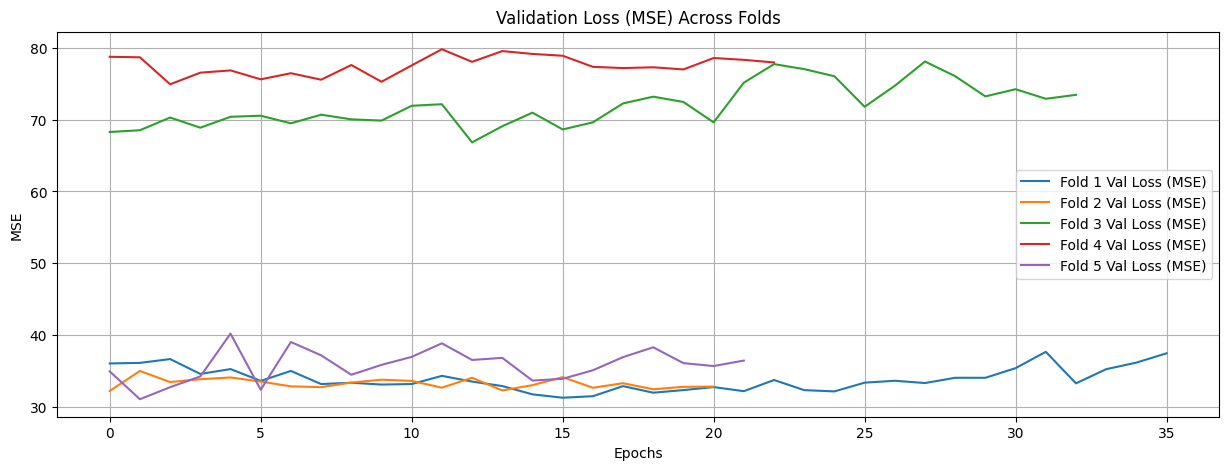

Overall R-squared on concatenated CV validation data: 0.0498
--- Performance by Age Category (on all CV validation samples) ---
  Category: Younger (Samples: 1571)
    MSE: 52.5245, MAE: 5.1098, R-squared: 0.0804
  Category: Older (Samples: 727)
    MSE: 38.5801, MAE: 4.8392, R-squared: -0.0631


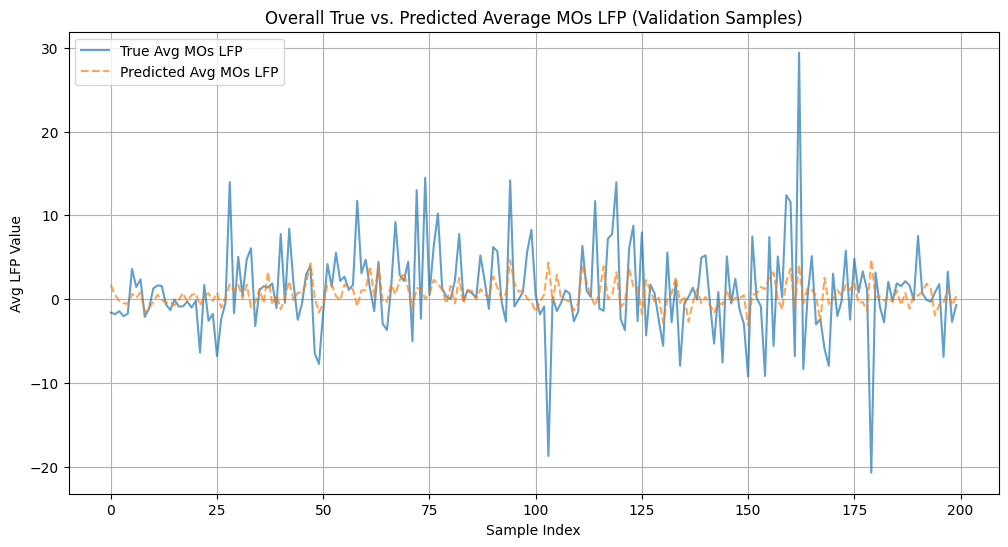

Script analysis section completed.


In [21]:
# Cell 8: Results Aggregation and Age-Based Evaluation

if 'X_final' not in globals() or not isinstance(X_final, np.ndarray) or X_final.size == 0 or 'Y_final' not in globals() or not isinstance(Y_final, np.ndarray) or Y_final.size == 0 or  not fold_val_mse: # Check if training actually ran and produced metrics
    print("Skipping results aggregation as training data is missing, metrics are not available, or X_final/Y_final are problematic.")
else:
    print("--- Cross-Validation Summary ---")
    # Use np.nanmean and np.nanstd for R2 scores as some folds might be NaN
    print(f"Average Validation MSE across {N_SPLITS_CV} folds: {np.nanmean(fold_val_mse):.4f} (+/- {np.nanstd(fold_val_mse):.4f})")
    print(f"Average Validation MAE across {N_SPLITS_CV} folds: {np.nanmean(fold_val_mae):.4f} (+/- {np.nanstd(fold_val_mae):.4f})")
    print(f"Average Validation R-squared across {N_SPLITS_CV} folds: {np.nanmean(fold_val_r2):.4f} (+/- {np.nanstd(fold_val_r2):.4f})")
    
    if fold_histories:
        plt.figure(figsize=(15, 5))
        for i, history_fold in enumerate(fold_histories):
            if history_fold and hasattr(history_fold, 'history') and 'val_loss' in history_fold.history:
                 plt.plot(history_fold.history['val_loss'], label=f'Fold {i+1} Val Loss (MSE)')
            else:
                 print(f"Warning: History for fold {i+1} is missing or malformed.")
        plt.title('Validation Loss (MSE) Across Folds')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("No training histories recorded to plot.")
        
    if all_y_true_val_folds and all_y_pred_val_folds and all_age_categories_val_folds:
        Y_true_all_cv = np.concatenate(all_y_true_val_folds, axis=0)
        Y_pred_all_cv = np.concatenate(all_y_pred_val_folds, axis=0)
        age_cat_all_cv = np.concatenate(all_age_categories_val_folds, axis=0)
        
        if Y_true_all_cv.shape[0] > 1 and len(np.unique(Y_true_all_cv.flatten())) > 1 :
            overall_r2 = r2_score(Y_true_all_cv, Y_pred_all_cv)
            print(f'Overall R-squared on concatenated CV validation data: {overall_r2:.4f}')
        else:
            print(f'Overall R-squared: Not enough samples or variance in Y_true_all_cv (found {Y_true_all_cv.shape[0]} samples)')

        print("--- Performance by Age Category (on all CV validation samples) ---")
        for category in ['Younger', 'Older']:
            cat_indices = (age_cat_all_cv == category)
            if np.any(cat_indices):
                y_true_cat = Y_true_all_cv[cat_indices]
                y_pred_cat = Y_pred_all_cv[cat_indices]
                if len(y_true_cat) > 1 and len(np.unique(y_true_cat.flatten())) > 1:
                    mse_cat = mean_squared_error(y_true_cat, y_pred_cat)
                    mae_cat = mean_absolute_error(y_true_cat, y_pred_cat)
                    r2_cat = r2_score(y_true_cat, y_pred_cat)
                    print(f'  Category: {category} (Samples: {len(y_true_cat)})')
                    print(f'    MSE: {mse_cat:.4f}, MAE: {mae_cat:.4f}, R-squared: {r2_cat:.4f}')
                else:
                    print(f'  Category: {category} (Samples: {len(y_true_cat)}) - Not enough samples or variance for R2 score.')
                    if len(y_true_cat) > 0: # Still print MSE/MAE if possible
                        print(f'    MSE: {mean_squared_error(y_true_cat, y_pred_cat):.4f}, MAE: {mean_absolute_error(y_true_cat, y_pred_cat):.4f}')
            else:
                print(f'  Category: {category} - No samples in validation set.')
                
        if Y_true_all_cv.shape[0] > 0:
            plt.figure(figsize=(12, 6))
            plot_samples = min(200, Y_true_all_cv.shape[0])
            plt.plot(Y_true_all_cv[:plot_samples, 0], label='True Avg MOs LFP', alpha=0.7)
            plt.plot(Y_pred_all_cv[:plot_samples, 0], label='Predicted Avg MOs LFP', linestyle='--', alpha=0.7)
            plt.title('Overall True vs. Predicted Average MOs LFP (Validation Samples)')
            plt.xlabel('Sample Index')
            plt.ylabel('Avg LFP Value')
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            print("No validation samples to plot true vs. predicted.")
    else:
        print("No validation predictions recorded to aggregate or plot by age.")
        
print("Script analysis section completed.")